# 12강 Kernel Methods 2

**참고 교재: Bishop (2006) Chapter 7**

12강에서는 커널 기법과 관련하여 다음의 내용들을 살펴본다.  

- **Soft-Margin SVM (C-SVM)**: Hard-Margin SVM이 적용되지 않는 일반적인 상황(즉, 학습 데이터가 linearly separable 하지 않을 수 있는 경우)에서 적용할 수 있는 보다 일반적인 SVM이다.
- **SVM for Regression (SVR)**: 기존 SVM이 분류 문제에 특화된 반면, **SVR**은 연속 값 예측(회귀) 문제로 확장한 모델이다.

## 1. Soft-Margin SVM (C-SVM)

### 1.1 Hard-Margin SVM의 한계
Hard-Margin SVM은 **데이터가 Linearly separable**하다고 가정한다. 하지만 현실 세계의 데이터는 노이즈나 클래스 간 중첩으로 인해 완벽하게 분리되지 않는 경우가 흔하다. 즉, 이러한 경우에 Linear separability를 억지로 맞추려 하면 **과적합**(Overfitting)이 발생하거나, 해가 존재하지 않을 수 있다. 그리하여, SVM에 **슬랙 변수(slack variable)** $\{\xi_n \ge 0\}$를 도입하여 일부 샘플이 마진을 침범하거나 틀리게 분류되도록 허용할 수 있다.

### 1.2 Soft-Margin 개념을 위한 슬랙 변수($\xi_n$) 도입

- 각 데이터 샘플 $ x_n $에 대응하는 $\xi_n \;(n=1, \cdots, N)$은 다음을 정량화하는 변수이다:
  - **마진을 얼마나 침범하는지**
  - 혹은 **오분류**가 어느 정도로 발생했는지
- $\xi_n = 0$이면 해당 샘플은 마진을 전혀 침범하지 않고 (Hard-Margin과 동일),  
- $\xi_n > 0$이면 샘플이 마진 안쪽에 있거나, 심지어 다른 클래스 쪽으로 넘어간 상태(오분류)를 의미한다.

Soft-Margin SVM을 Hard-Margin SVM과 비교하면 다음의 차이가 존재한다:
- **Hard-Margin**: 모든 샘플이 초평면 바깥쪽(자신의 클래스 쪽)에 있으며, 침범하지 않는다 ($\xi_n = 0$).  
- **Soft-Margin**: 일부 샘플이 어쩔 수 없이 마진을 침범($\xi_n > 0$), 혹은 오분류($\xi_n > 1$)되더라도, 전체 모델의 일반화 성능과 마진 확보의 균형을 잡는다.

그리하여, Soft-Margin SVM은 다음의 장점이 존재한다:
- **현실성**: 노이즈나 중첩이 있는 데이터에 대해 실제로 사용 가능  
- **오분류 허용**: 모델이 약간의 오분류를 허용함으로써 오버피팅을 피하고, 복잡한 데이터에도 잘 대응  
- **Hard-Margin 확장**: $C \to \infty$로 가면 Hard-Margin과 유사해짐(이론적으로).

### 1.3 Soft-Margin SVM의 프라이멀 문제 

$$
\begin{aligned}
& \min_{\mathbf{w}, b,\, \boldsymbol{\xi}} \quad 
  \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{n=1}^N \xi_n, \\
& \text{subject to} \quad
  t_n \bigl(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b\bigr) \;\ge\; 1 - \xi_n, \\
& \qquad\qquad\quad\;\;\, \xi_n \,\ge\, 0
  \quad (\text{for all } \; n=1, \cdots, N)
\end{aligned}
$$

- $\mathbf{w}$, $b$: 결정 초평면의 마진을 정의하는 파라미터  
- $\boldsymbol{\xi} = [\xi_1 , \xi_2 , \cdots, \xi_N ]^T$: 각 샘플이 분류 초평면의 마진을 침범하는 정도 (오분류까지 포함)  
- $C > 0$: **trade-off constant**로서 마진 크기와 오분류(침범) 비용 간의 트레이드오프를 사용자가 직접 조절

위의 Soft-Margin SVM의 프라이멀 문제에 대한 해석은 다음과 같다:
- $\tfrac12 \|\mathbf{w}\|^2$ 항: 마진을 최대화하려는 항(마진 폭에 역비례)  
- $C \sum_{n=1}^N \xi_n$ 항: 전체 침범 정도(오분류 정도)에 대한 페널티  
- $C$가 **큰 경우**: 침범(오분류)을 강하게 페널티 → Hard-Margin에 가까운 해를 유도  
- $C$가 **작은 경우**: 침범(오분류)에 대한 페널티가 작아져 더 넓은 마진을 허용(그러나 오분류 샘플이 증가할 수 있음)

### 1.4 Soft-Margin SVM의 듀얼 문제

프라이멀 문제의 부등식 제약조건들을 반영하여 다음과 같이 **제약조건** $\le$ 0 형태 및, **라그랑주 승수** $\ge$ 0 형태인 라그랑지안을 정의한다.

$$
\begin{align}
&\mathcal{L}(\mathbf{w}, b, \boldsymbol{\xi}, \boldsymbol{\alpha}, \boldsymbol{\mu}) \\
=& \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{n=1}^N \xi_n +\sum_{n=1}^N \alpha_n \Bigl[1 - \xi_n - t_n \left(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b\right)\Bigr] - \sum_{n=1}^N \mu_n \xi_n
\end{align}
$$

위 라그랑지안을 $\mathbf{w}, b, \boldsymbol{\xi}$에 대해 최소화하고, $\boldsymbol{\alpha}$에 대해 정리하면 듀얼 문제가 유도된다.

$$
\begin{align}
\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 0
\;&\Longrightarrow\;
\mathbf{w} = \sum_{n=1}^N \alpha_n t_n \boldsymbol{\phi}(x_n),\\
\frac{\partial \mathcal{L}}{\partial b} = 0
\;&\Longrightarrow\;
\sum_{n=1}^N \alpha_n t_n = 0,\\
\frac{\partial \mathcal{L}}{\partial \xi_n} = 0
\;&\Longrightarrow\;
\alpha_n = C - \mu_n \in [0, C], \quad n=1,\cdots, N.
\end{align}
$$


그리하여, 다음과 같은 듀얼 문제로 정리 된다:

$$
\begin{aligned}
 \max_{\boldsymbol{\alpha}}& \quad W(\boldsymbol{\alpha}) 
= \sum_{n=1}^N \alpha_n - \frac{1}{2} \sum_{n=1}^N \sum_{m=1}^N \alpha_n \alpha_m \,t_n t_m \,\boldsymbol{\phi}(x_n)^T \boldsymbol{\phi}(x_m), \\
 \text{subject to} &\quad \sum_{n=1}^N \alpha_n t_n = 0, \quad \alpha_n \in [0, C] \quad (n=1,\cdots,N).
\end{aligned}
$$


### 1.5 KKT (Karush-Kuhn-Tucker) 조건 

1. **Stationarity 조건**  
   $$
   \mathbf{w} = \sum_{n=1}^N \alpha_n t_n \boldsymbol{\phi}(x_n),\quad\sum_{n=1}^N \alpha_n t_n = 0,\quad\alpha_n  \in [0, C], \quad n=1,\cdots, N.
   $$

2. **Primal feasibility (프라이멀 타당성)**

   $$1 -\xi_n -t_n \bigl(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b \bigr) \le 0, \quad \xi_n \ge 0,\quad n=1,\dots,N.
   $$

4. **Dual feasibility (듀얼 타당성)**  
   $$
   \alpha_n \ge 0, \quad \mu_n \ge 0, \quad n=1,\dots,N.
   $$

5. **Complementary slackness (상호 보완성)**  
   $$
   \alpha_n \bigl[1 - \xi_n -t_n\left(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b\right)\bigr] = 0,\quad \mu_n \xi_n = 0,\quad n=1,\dots,N.
   $$


### 1.6 C-SVM 핵심 포인트 정리

1. **Soft-Margin 도입 배경**  
   - 실제 데이터가 완벽 분리가 어려움.  
   - 노이즈, 오표기, 분포 중첩 문제 극복.
   - 완벽 분리가 불가능하거나 오버피팅이 우려될 때, Soft-Margin SVM은 유용한 대안.
     
2. **수식 정리** (프라이멀 문제)
$$
\begin{aligned}
\min_{\mathbf{w}, b, \boldsymbol{\xi}} \quad 
   & \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{n=1}^N \xi_n, 
\\
\text{subject to} \quad 
   & t_n \bigl(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b \bigr) \;\ge\; 1 - \xi_n,\\
   & \xi_n \;\ge\; 0, \quad \text{for all }\;n.
\end{aligned}
$$


3. **$C$ 파라미터 해석**  
   - 크면 오분류를 강하게 억제 (Hard-Margin에 가까움).  
   - 작으면 마진을 크게 쓰고 오분류를 어느 정도 허용.

4. **하이퍼파라미터 튜닝**: 교차 검증(Cross-Validation) 등 사용
   - $C$ 값을 적절히 튜닝 
   - 커널 함수 적용 시 (예: RBF 커널의 $\gamma$) 추가 하이퍼파라미터 값을 적절히 튜닝.

5. **정리**  
   - Soft-Margin SVM은 Hard-Margin SVM의 원리를 노이즈/오분류를 허용할 수 있도록 확장한 모델이다.
   - 슬랙 변수를 도입해 마진 침범 혹은 오분류 샘플을 허용하고, 그 정도에 비례해 패널티를 부여함으로써, 실제 데이터셋에서 뛰어난 일반화 성능과 유연성을 확보할 수 있다.

## 2. Soft-Margin SVM 파이썬 예제

linearly separable 하지 않은 데이터셋으로 살짝 겹치는 이변량 정규분포 데이터를 사용, Soft-Margin SVM을 구현해보자.

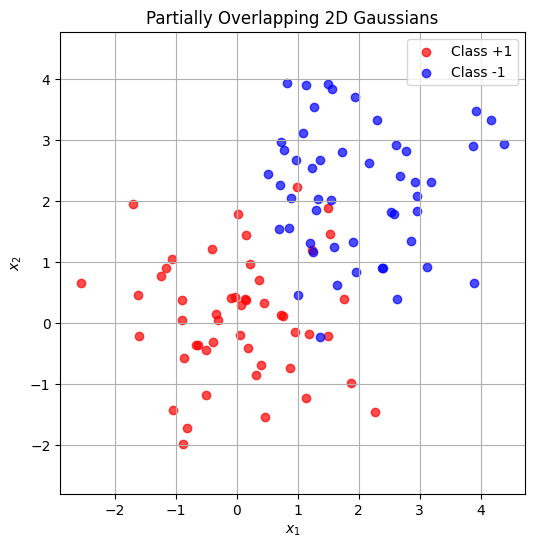

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ----------------------------------------------------
# 1) 예시 데이터: 겹치는 두 이변량 정규분포 샘플
# ----------------------------------------------------
np.random.seed(0)

mean_plus = [0, 0]
mean_minus = [2, 2]
cov = [[1, 0],
       [0, 1]]

N = 50

# +1 클래스
X_plus = np.random.multivariate_normal(mean_plus, cov, N)
t_plus = np.ones(N)

# -1 클래스
X_minus = np.random.multivariate_normal(mean_minus, cov, N)
t_minus = -np.ones(N)

# 두 클래스를 합쳐서 트레이닝 데이터셋 생성
X = np.vstack((X_plus, X_minus))  # shape = (2N, 2)
t = np.concatenate((t_plus, t_minus))  # shape = (2N,)


# -------------------------------
# 2) 데이터 시각화
# -------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(X_plus[:, 0], X_plus[:, 1], c='red', alpha=0.7, label='Class +1')
plt.scatter(X_minus[:, 0], X_minus[:, 1], c='blue', alpha=0.7, label='Class -1')
plt.title("Partially Overlapping 2D Gaussians")
plt.legend()
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis("equal")
plt.grid(True)
plt.show()

**Soft-Margin SVM**이 Hard-Margin SVM과 다른 점 (코드 상에서): `fit_svm_rbf_soft` 함수에서 `0 <= alpha_n <= C`의 bound가 추가된 것 말고는 전부 동일하다. 
   - $\alpha_n \le C$는 소프트 마진에서 **슬랙 변수** 및 오류에 대한 페널티가 제한되는 효과와 대응된다.  
   - `C`가 큰 값이면 하드 마진에 가까워지고, 작은 값이면 오분류를 좀 더 허용하는 해를 얻게 된다.

Optimization terminated successfully    (Exit mode 0)
            Current function value: -22.80511528715519
            Iterations: 32
            Function evaluations: 3235
            Gradient evaluations: 32

 alpha: [1.00000000e+00 1.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.00000000e+00 7.76376202e-01 1.17564403e-15
 1.00000000e+00 0.00000000e+00 7.26078254e-01 0.00000000e+00
 8.50677668e-01 1.07927214e-15 1.00000000e+00 1.46048662e-16
 7.01481270e-01 1.37792510e-15 1.00000000e+00 0.00000000e+00
 1.24721643e-01 7.53106783e-01 1.57429339e-01 2.12428603e-01
 5.03747135e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 2.18221384e-16 0.00000000e+00 0.00000000e+00 1.22107716e-15
 1.16134535e-16 1.15505606e-15 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 2.26790636e-01 9.00592805e-16
 0.00000000e+00 6.68165255e-01 1.00000000e+00 8.23485037e-01
 0.00000000e+00 0.00000000e+00 4.47911368e-15 1.00000000e+00
 1.00000000e+00 4.31735391e-16 8.59872384e-01 0

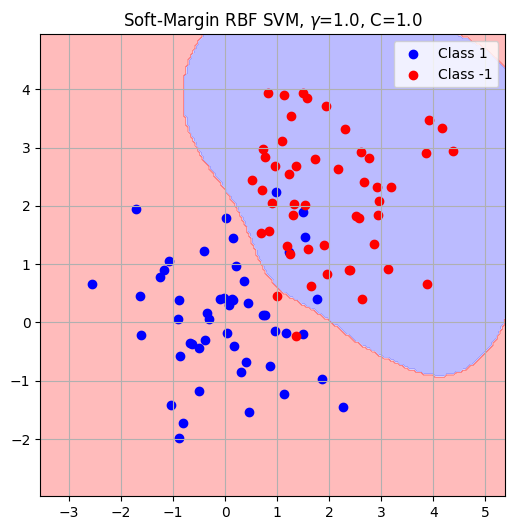

In [4]:
# ----------------------------------------------------
# 3) RBF Kernel
# ----------------------------------------------------
def rbf_kernel(x1, x2, gamma):
    return np.exp(-gamma * np.sum((x1 - x2)**2))

def compute_kernel_matrix(X, gamma):
    N = len(X)
    K = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            K[i, j] = rbf_kernel(X[i], X[j], gamma)
    return K

# ----------------------------------------------------
# 4) 결정 함수, 예측 함수, 결정 경계 시각화 
# ----------------------------------------------------
def decision_function(alpha, b, X_train, t_train, gamma, X_test):
    """
    f(x) = sum_n alpha_n * t_n * K(x_n, x) + b
    """
    out = []
    for x in X_test:
        val = b
        for i in range(len(X_train)):
            if alpha[i] > 1e-8:
                val += alpha[i] * t_train[i] * rbf_kernel(X_train[i], x, gamma)
        out.append(val)
    return np.array(out)

def predict(alpha, b, X_train, t_train, gamma, X_test):
    vals = decision_function(alpha, b, X_train, t_train, gamma, X_test)
    return np.sign(vals)

def plot_decision_boundary(alpha, b, X, t, gamma, title="RBF SVM"):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(alpha, b, X, t, gamma, grid_points)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.bwr)

    for label, marker, color in zip([1, -1], ['o', 'o'], ['blue', 'red']):
        plt.scatter(X[t == label, 0], X[t == label, 1],
                    marker=marker, c=color, label=f"Class {label}")

    plt.title(title)
    plt.legend()
    plt.grid(True)


# ----------------------------------------------------
# 5) Soft-Margin RBF SVM
# ----------------------------------------------------
#
# 프라이멀에서는 파라미터 'C'와 slack variable을 고려하지만,
# 듀얼에서는 alpha_n <= C가 추가 제약이 된다.
# 즉, 소프트 마진에서는:
#   0 <= alpha_n <= C
#

def dual_objective_soft(alpha, t, K):
    """
    Dual objective:
       maximize W(alpha) = sum(alpha_n) - 1/2 sum_{n,m} alpha_n alpha_m t_n t_m K(n,m)
    We'll minimize the negative of W(alpha).
    """
    term1 = 0.5 * np.sum((alpha * t)[:, None] * (alpha * t)[None, :] * K)
    term2 = np.sum(alpha)
    return term1 - term2

def fit_svm_rbf_soft(X, t, gamma, C):
    """
    Solve the Soft-Margin SVM dual problem:
       0 <= alpha_n <= C
       sum_n alpha_n t_n = 0
    """
    N = len(X)
    K = compute_kernel_matrix(X, gamma=gamma)

    alpha0 = np.zeros(N)
    
    def eq_constraint(alpha):
        return np.dot(alpha, t)

    constraints = [{'type': 'eq', 'fun': eq_constraint}]
    bounds = [(0, C)] * N # 소프트 마진: alpha_n <= C

    res = minimize(
        fun=dual_objective_soft,
        x0=alpha0,
        args=(t, K),
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000, 'disp': True}
    )
    alpha_opt = res.x

    # b 계산 (KKT)
    sv_indices = np.where((alpha_opt > 1e-8) & (alpha_opt <= C ))[0]
    if len(sv_indices) == 0:
        b_opt = 0.0
    else:
        b_list = []
        for i in sv_indices:
            sum_j = np.sum(alpha_opt * t * K[i, :])
            b_i = t[i] - sum_j
            b_list.append(b_i)
        b_opt = np.mean(b_list)

    return alpha_opt, b_opt

# ----------------------------------------------------
# 6) 예시 실행 (gamma와 C값을 튜닝 해볼 것)
# ----------------------------------------------------
gamma = 1.0
C = 1.0

alpha, b = fit_svm_rbf_soft(X, t, gamma=gamma, C=C)
print("\n alpha:", alpha)
print("b:", b)

plt.figure(figsize=(6,6))
plot_decision_boundary(alpha, b, X, t, gamma,
                           title=rf"Soft-Margin RBF SVM, $\gamma$={gamma}, C={C}")
plt.show()

## 3. Support Vector Regression (SVR)

이제 **Support Vector Regression**에 대해서 알아보자.

- **SVM for Regression**: 기존 SVM이 분류 문제에 특화된 반면, **SVR**은 연속 값 예측(회귀) 문제로 확장한 모델이다.
- **핵심 아이디어**: 회귀 예측 선(또는 초평면) 주변에 **$\varepsilon$-tube**를 설정하고, 그 내부의 오차는 무시($\varepsilon$-insensitive)하며, 튜브 바깥으로 벗어난 샘플에 대해서만 비용($\xi, \hat{\xi}$)을 부여한다.

### 3.1 $\varepsilon$-insensitive 손실 함수

$$
|\,t_n - y(x_n)\,|_\varepsilon 
\;=\;
\max\Bigl(\,|\,t_n - y(x_n)\,| - \varepsilon,\; 0\Bigr),
$$
- 예측값 $ y(x_n) $이 **$\varepsilon$-tube** 내부에 있으면 손실이 0.
- $\varepsilon$-tube 범위를 벗어나면, 초과분만큼 손실로 계산.

### 3.2 직관적 해석

- $\varepsilon$-tube 내 샘플들은 “오차로 취급하지 않음”  
- 모델이 $\varepsilon$ 범위 내에 정확히 들어오도록 유도하되, 튜브 밖(과도하게 벗어난 샘플)에 대해서만 비용(슬랙 변수 $\xi, \hat{\xi}$)을 부여 → 오버피팅 방지 효과.

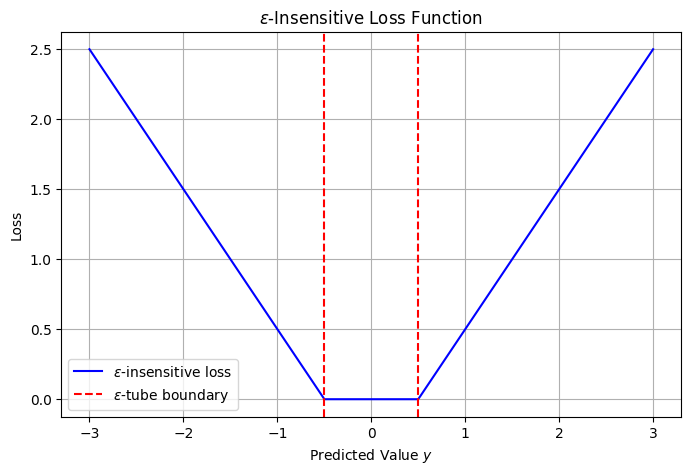

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Define the epsilon-insensitive loss function
def epsilon_insensitive_loss(t, y, e):
    return np.maximum(np.abs(t - y) - e, 0)

# Generate data for plotting
t = 0  # target
y = np.linspace(-3, 3, 500)  # Predicted values
e = 0.5  # Epsilon value

# Calculate loss
loss = epsilon_insensitive_loss(t, y, e)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(y, loss, label=r'$\epsilon$-insensitive loss', color='blue')
plt.axvline(t + e, color='red', linestyle='--', label=r'$\epsilon$-tube boundary')
plt.axvline(t - e, color='red', linestyle='--')

plt.title(r'$\epsilon$-Insensitive Loss Function')
plt.xlabel('Predicted Value $y$')
plt.ylabel('Loss')
plt.legend()
plt.grid()

### 3.3 SVR의 프라이멀 문제 (Primal Formulation)

#### 3.3.1 회귀 초평면(Regression Hyperplane)

$$
y(x) 
\;=\;
\mathbf{w}^T\boldsymbol{\phi}(x) + b,
$$
- $\boldsymbol{\phi}(x)$: (고차원) 특징 공간으로 매핑
- $\mathbf{w}, b$: 회귀 초평면 파라미터

#### 3.3.2 $\varepsilon$-SVR의 프라이멀 문제

$$
\begin{aligned}
\min_{\mathbf{w}, b, \,\boldsymbol{\xi}, \,\boldsymbol{\hat{\xi}}} \quad
& \frac{1}{2}\,\|\mathbf{w}\|^2
  \;+\;
  C \sum_{n=1}^N \bigl(\,\xi_n + \hat{\xi}_n\bigr) 
\\ 
\text{subject to}\quad
& \xi_n \;\ge\; 0,\quad \hat{\xi}_n \;\ge\; 0, \quad  n=1,\dots,N,
\\
& \xi_n \;\ge\; t_n \;-\; \bigl(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b\bigr) \;- \varepsilon , \quad  n=1,\dots,N,
\\
& \hat{\xi}_n \;\ge\; \bigl(\mathbf{w}^T \boldsymbol{\phi}(x_n) + b\bigr) - t_n \;- \varepsilon, \quad  n=1,\dots,N.
\end{aligned}
$$

- $\xi_n, \hat{\xi}_n$: **슬랙 변수(slack variables)**. $\varepsilon$-tube를 넘어서는 양쪽 오차들을 나타냄.
- $C>0$: 모델의 복잡도(마진 폭)와 오차($\xi_n$, $\hat{\xi}_n$) 사이의 트레이드오프를 조절.

#### 3.3.3 목적함수 해석

- $\tfrac{1}{2}\|\mathbf{w}\|^2$: 회귀 초평면의 기울기(norm)을 의미하며, 이것을 작게 만들수록 회귀 모델을 '평평'하게, 즉, 복잡도를 낮게 만들어 $y(x)$가 지나치게 급변하지 않도록(오버피팅 방지) 하는 효과가 있음. 이 항이 최소화될수록 모델 복잡도가 낮아지며, 일반화 성능이 좋아질 가능성이 증가함.
- $\sum (\xi_n + \hat{\xi}_n)$: $\varepsilon$-튜브를 벗어난 샘플(오차)에 대한 패널티 합.
- $C$: 슬랙 변수(오차)에 대한 페널티 강도. 큰 값일수록 오차를 최대한 줄이기에 더 정밀하게 맞추지만, $\|\mathbf{w}\|^2$가 커져서 과적합 위험 증가. 작은 값이면 오차를 좀 더 허용하고, 모델이 단순해지지만, 예측 오차가 클 수 있음 (언더피팅 위험).

### 3.4 SVR의 듀얼 문제 (Dual Formulation)

위의 QP 문제의 최적화를 위하여 라그랑지안을 정의해보자.

$$
\begin{align}
\mathcal{L}_P =& \frac{1}{2}\,\|\mathbf{w}\|^2 + C \sum_{n=1}^N \bigl(\,\xi_n + \hat{\xi}_n\bigr) - \sum_{n=1}^N \alpha_n (\varepsilon + \xi_n + y_n -t_n ) \\&- \sum_{n=1}^N \hat{\alpha}_n (\varepsilon + \hat{\xi}_n - y_n +t_n )- \sum_{n=1}^N (\mu_n \xi_n + \hat{\mu}_n \hat{\xi}_n )
\end{align}
$$


유도한 라그랑지안을 이용하여 KKT 조건을 확인해보자.

1. **Stationarity 조건**  

$$
\begin{align}
\frac{\partial \mathcal{L}_P}{\partial \mathbf{w}} = 0
\;&\Longrightarrow\;
\mathbf{w} = \sum_{n=1}^N (\alpha_n - \hat{\alpha}_n )\boldsymbol{\phi}(x_n),\\
\frac{\partial \mathcal{L}_P}{\partial b} = 0
\;&\Longrightarrow\;
\sum_{n=1}^N (\alpha_n  - \hat{\alpha}_n ) = 0,\\
\frac{\partial \mathcal{L}_P}{\partial \xi_n} = 0
\;&\Longrightarrow\;
\alpha_n \in [0, C], \quad n=1,\cdots, N,\\
\frac{\partial \mathcal{L}_P}{\partial \hat{\xi}_n} = 0
\;&\Longrightarrow\;
\hat{\alpha}_n  \in [0, C], \quad n=1,\cdots, N.
\end{align}
$$


2. **Primal feasibility (프라이멀 타당성)**

   $$
\left.
   \begin{align}& \xi_n \;\ge\; 0,\quad \hat{\xi}_n \;\ge\; 0, 
\\
& -\varepsilon - \xi_n - y_n +t_n \le 0, 
\\
& -\varepsilon - \hat{\xi}_n + y_n -t_n \le 0,
   \end{align}
   \right\}\quad  n=1,\dots,N.$$

3. **Dual feasibility (듀얼 타당성)**  
   $$
   \alpha_n \ge 0, \quad \hat{\alpha}_n \ge 0, \quad \mu_n \ge 0,\quad \hat{\mu}_n \ge 0, \quad n=1,\dots,N.
   $$

4. **Complementary slackness (상호 보완성)**  
   $$
   \left.
   \begin{align}
   \alpha_n (\varepsilon + \xi_n + y_n -t_n ) = 0, \\
   \hat{\alpha}_n (\varepsilon + \xi_n - y_n +t_n ) = 0,\\
   \mu_n \xi_n = 0,\quad \hat{\mu}_n \hat{\xi}_n = 0,
   \end{align} \right\} \quad n=1,\dots,N.
   $$

SVR에서도 실제 계산 시, $\boldsymbol{\phi}(x)$를 직접 다루지 않고 **커널** $k(x,x')$을 사용하는 **커널 트릭**을 통해 고차원 회귀를 효율적으로 수행할 수 있다. 그리하여, 위 라그랑지안을 듀얼 변수들로 정리하면 (RBF 커널 기준) 다음과 같이 요약할 수 있다.

**듀얼 문제 (Dual Problem)**:
$$
\begin{aligned}
\max_{\alpha,\hat{\alpha}} \quad
& -\frac{1}{2}
  \sum_{n=1}^N \sum_{m=1}^N
  (\alpha_n - \hat{\alpha}_n)\,(\alpha_m - \hat{\alpha}_m)\,k(x_n, x_m) \\
  & -\;
  \varepsilon \sum_{n=1}^N (\alpha_n + \hat{\alpha}_n)
  \;+\;
  \sum_{n=1}^N t_n\,(\alpha_n - \hat{\alpha}_n),
\\
\text{subject to} \quad
& \sum_{n=1}^N (\alpha_n - \hat{\alpha}_n) = 0,
\\
& 0 \;\le\; \alpha_n \;\le\; C,
\quad
  0 \;\le\; \hat{\alpha}_n \;\le\; C,
\quad n=1,\dots,N.
\end{aligned}
$$
여기서,
- $ \alpha_n, \hat{\alpha}_n $는 각각 $\varepsilon$-튜브 위·아래쪽 초과분을 보정하는 라그랑주 승수  
- $ k(x_n, x_m) $는 RBF 커널($\exp(-\gamma\|x_n - x_m\|^2)$)  
- $C$와 $\varepsilon$은 하이퍼파라미터

위 식을 vector-matrix notation으로 정리하면 다음과 같다.
$$
\min_{\boldsymbol{\alpha},\boldsymbol{\hat{\alpha}}} \quad \frac{1}{2} (\boldsymbol{\alpha}-\boldsymbol{\hat{\alpha}})^T K_{n,m}  (\boldsymbol{\alpha}-\boldsymbol{\hat{\alpha}}) + \begin{bmatrix}
\varepsilon \mathbf{1}_N \\ \varepsilon \mathbf{1}_N
\end{bmatrix}^T \begin{bmatrix}
\boldsymbol{\alpha} \\ \boldsymbol{\hat{\alpha}}
\end{bmatrix} - \begin{bmatrix}
\mathbf{t} \\ -\mathbf{t}
\end{bmatrix}^T \begin{bmatrix}
\boldsymbol{\alpha} \\ \boldsymbol{\hat{\alpha}}
\end{bmatrix},
$$
$$
\begin{aligned}
\text{subject to} \quad
& \begin{bmatrix}
 \mathbf{1}_N \\  \mathbf{1}_N
\end{bmatrix}^T \begin{bmatrix}
\boldsymbol{\alpha} \\ \boldsymbol{\hat{\alpha}}
\end{bmatrix} = 0,
\\
& \begin{bmatrix}
0 \\ \vdots \\ 0
\end{bmatrix} \le 
\begin{bmatrix}
\boldsymbol{\alpha} \\ \boldsymbol{\hat{\alpha}}
\end{bmatrix} \le
\begin{bmatrix}
C \\ \vdots \\ C
\end{bmatrix}.
\end{aligned}
$$

### 3.5 결정 함수

위 문제를 최소화하면, 결과적으로 **결정 함수**(예측 식)은

$$
y(x) = \sum_{n=1}^N (\alpha_n - \hat{\alpha}_n) \, k(x_n, x) + b,
$$

형태가 된다. 여기서 $b$는 여러 서포트 벡터, 즉, $\alpha_n$ 또는 $\hat{\alpha}_n$이 $(0,C)$ 사이에 있는 지점들을 골라서 $\alpha_n,\hat{\alpha}_n$ 중 어느 쪽이 **0이 아닌지**(즉, $\varepsilon$-튜브 아래쪽 초과인지 위쪽 초과인지)에 따라, $b$를 다음과 같은 식으로 구한다:

$$
b
= t_n - \varepsilon \,\mathrm{sgn}\bigl(\alpha_n - \hat{\alpha}_n\bigr) - \sum_{m=1}^N (\alpha_m - \hat{\alpha}_m) k(x_m, x_n).
$$

여기서,
- $\mathrm{sgn}(\alpha_n - \hat{\alpha}_n)$은 "$\alpha_n > 0$이면 -1", "$\hat{\alpha}_n > 0$이면 +1" 이런식으로  **튜브 아래·위** 구분을 반영하는 부호 함수이다.  
- 실제 구현에서는, **$0 < \alpha_n < C$** 또는 **$0 < \hat{\alpha}_n < C$** 인 서포트 벡터들을 찾아서 해당 점들에 대해 **KKT 조건**으로부터 $b$의 평균을 사용한다.


1. **$\hat{\alpha}_n = 0$이며 $0 < \alpha_n < C$인 경우**  
   - 예측값이 $t_n$보다 **작아서** $\varepsilon$-튜브를 벗어난 점(“아래쪽” 초과)  
   - 이때  
     $$
       b 
       = 
       y_n 
       \;-\;
       \varepsilon 
       \;-\;
       \sum_{j=1}^N
         (\alpha_j - \hat{\alpha}_j) \,K(x_j, x_n).
     $$

2. **$\alpha_n = 0$이며 $0 < \hat{\alpha}_n < C$인 경우**  
   - 예측값이 $t_n$보다 **커서** $\varepsilon$-튜브를 벗어난 점(“위쪽” 초과)  
   - 이때  
     $$
       b 
       =
       y_n
       \;+\;
       \varepsilon
       \;-\;
       \sum_{j=1}^N
         (\alpha_j - \hat{\alpha}_j) \,K(x_j, x_n).
     $$

### 3.6 정리하기

- $\varepsilon$-SVR은 $\varepsilon$-tube 범위를 벗어난 오차($\xi_n,\hat{\xi}_n$)만 비용으로 삼아, 회귀 모델의 복잡도($\|\mathbf{w}\|$)와 오차 사이에 균형을 잡는 머신러닝 모델이다.

- 프라이멀 문제에서는 $\tfrac12\|\mathbf{w}\|^2 + C\sum(\xi_n+\hat{\xi}_n)$을 최소화하고, $\xi_n,\hat{\xi}_n$는 $\varepsilon$-tube 밖으로 벗어난 정도를 나타낸다.

- 듀얼 문제에서는 $\alpha_n,\hat{\alpha}_n$을 사용하여 표현되며, $k(x_n,x_m)$ 같은 **커널**을 통해 고차원 회귀를 효율적으로 계산한다.

- 최적해를 얻으면 결정 함수는 
   $$
   y(x)=\sum_{n=1}^N (\alpha_n-\hat{\alpha}_n)k(x_n,x)+b
   $$
   형태가 되고, $\alpha_n,\hat{\alpha}_n$은 
   $$
   0\le\alpha_n,\hat{\alpha}_n\le C,\quad \sum_{n=1}^N (\alpha_n-\hat{\alpha}_n)=0
   $$
   을 만족한다.

- 바이어스 $b$는 **KKT 조건**을 통해 결정되며, 이 때 **$\varepsilon$-튜브 위·아래 경계 중 어디에** 속하는지에 따라 $\pm \varepsilon$이 결정된다.  
- 여러 서포트 벡터에 대해서 구한 $b$들을 **평균**해서 사용하면 수치적으로 좀 더 안정적이다.  

## 4. SVR 파이썬 예제 

**SVR**의 경우, label이 연속이기 때문에 이 변수에 한 축을 담당하고, 2차원 이상의 feature를 사용할 경우 시각화에 불리하므로 학습 측면에서 1차원 feature 예제를 고려한다. **2차 다항식** 위에 노이즈를 추가한 예제 데이터를 만들고, **RBF(Radial Basis Function) 커널** 함수를 활용하여 비선형 회귀 문제를 풀어보자.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 데이터 생성 (2차 다항식)
np.random.seed(42)
N = 30
X = np.linspace(-3, 3, N).reshape(-1, 1)   # (N,1) shape

# 2차식: y_true = 0.5 * x^2 + 0.5 * x + 1.0
y_true = 0.5 * (X ** 2).squeeze() + 0.5 * X.squeeze() + 1.0

# 노이즈 추가
noise = np.random.normal(0, 1.0, size=N)
t = y_true + noise

In [2]:
# RBF Kernel 함수
def rbf_kernel(x1, x2, gamma=0.5):
    """RBF 커널: exp(-gamma * ||x1 - x2||^2)"""
    # x1, x2가 shape (1,)라고 가정
    diff = float(x1[0] - x2[0])  # -> 스칼라 변환
    return np.exp(-gamma * (diff**2))

def build_kernel_matrix(X, gamma=0.5):
    """X(1D): shape (N,1) -> NxN RBF 커널 행렬"""
    N = len(X)
    K = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            K[i, j] = rbf_kernel(X[i], X[j], gamma=gamma)
    return K

- `rbf_kernel(x1, x2, gamma=0.5)`
  - 기본 형태: $\exp(-\gamma \|x_1 - x_2\|^2)$  
  - 여기서는 1차원 입력만 다룬다고 가정하므로, `diff = float(x1[0] - x2[0])`로 스칼라 차이를 구한다.  
- `build_kernel_matrix(X, gamma=0.5)`  
  - 주어진 샘플 $X$ (크기 $N \times 1$)에 대해, $N \times N$ 크기의 RBF 커널 행렬 $K$를 생성한다.  
  - 각 원소 `K[i, j]`는 `X[i]`와 `X[j]` 사이의 RBF 커널 값을 의미한다.

이렇게 생성된 **RBF 커널 행렬**은 커널 회귀나 가우시안 프로세스 회귀 등 **비선형 모델링**에 응용할 수 있다.


In [3]:
# SVR 듀얼 목적함수
def svr_dual_objective(a, t, K, epsilon):
    # a = [alpha_1, ..., alpha_N, alpha^_1, ..., alpha^_N]
    N = len(t)
    alpha = a[:N]
    alpha_hat = a[N:]
    # 1) 0.5 * sum_{i,j} (alpha_i - alpha_hat_i)(alpha_j - alpha_hat_j)K[i,j]
    diff = alpha - alpha_hat
    term1 = 0.5 * np.sum((diff[:,None] * diff[None,:]) * K)

    # 2) epsilon * sum_i (alpha_i + alpha_hat_i)
    term2 = epsilon * np.sum(alpha + alpha_hat)

    # 3) - sum_i y_i (alpha_i - alpha_hat_i)
    term3 = - np.sum(t * diff)

    return term1 + term2 + term3

# 제약조건 함수
def constraint_sum_alpha(a, t):
    """sum_i (alpha_i - alpha^_i) = 0"""
    N = len(t)
    alpha = a[:N]
    alpha_hat = a[N:]
    return np.sum(alpha - alpha_hat)

- **`svr_dual_objective`**: 듀얼 목적함수
  - **$\alpha_n$, $\hat{\alpha}_n$**: SVR의 듀얼 변수들(각각 0 이상 $C$ 이하).
  - **`diff`**: 듀얼 변수 차이를 벡터로 구현하여 목적함수를 간단히 표현
  - 목적함수의 구성:
    1. $\tfrac12 \sum_{n,m} (\alpha_n - \hat{\alpha}_n)(\alpha_m - \hat{\alpha}_m) K_{n,m}$
    2. $\varepsilon \sum_n (\alpha_n + \hat{\alpha}_n)$
    3. $- \sum_n t_n (\alpha_n - \hat{\alpha}_n)$
- **`constraint_sum_alpha`**
  - $\sum_n (\alpha_n - \hat{\alpha}_n) = 0$를 만족해야 하는 **등식 제약**을 정의한다.

In [4]:
# SVR 학습 함수
def fit_epsilon_svr_rbf(X, t, C, epsilon, gamma):
    N = len(X)
    K = build_kernel_matrix(X, gamma=gamma)

    # 초기값
    alpha_init = np.zeros(N)
    alpha_hat_init = np.zeros(N)
    vars_init = np.concatenate([alpha_init, alpha_hat_init])

    # 제약 조건 (등식 제약)
    eq_cons = {'type': 'eq', 'fun': constraint_sum_alpha, 'args': (t,)}

    # alpha, alpha^* 범위 지정 ([0, C])
    bounds = [(0, C)] * (2*N)

    res = minimize(
        fun=svr_dual_objective,
        x0=vars_init,
        args=(t, K, epsilon),
        constraints=[eq_cons],
        bounds=bounds,
        options={'maxiter': 500, 'disp': True}
    )
    alpha_opt = res.x[:N]
    alpha_hat_opt = res.x[N:]
    return alpha_opt, alpha_hat_opt, K

- **`fit_epsilon_svr_rbf`**: SVR 학습 함수
  - **`build_kernel_matrix(X, gamma)`**: RBF 커널 행렬 $K$ 구성.
  - **`vars_nnit`**: $\boldsymbol{\alpha}, \boldsymbol{\hat{\alpha}}$ 변수들을 초기화 (0으로 시작).
  - **`eq_cons`**: `constraint_sum_alpha`를 통해 $\sum_n (\alpha_n - \hat{\alpha}_n) = 0$ 조건을 `minimize` 알고리즘에 전달.
  - **`bounds`**: 각 $\alpha_n$와 $\hat{\alpha}_n$는 모두 $[0, C]$ 범위.
  - **`minimize(...)`**: 듀얼 문제의 목적함수를 최적화하며 결과로 최적 해 `alpha_opt`, `alpha_hat_opt`를 반환.

In [5]:
# 상수항 b 계산함수
def compute_b(alpha, alpha_hat, X, t, K, epsilon, C):
    """
    b = 평균_{i ∈ SV} [ t_i - epsilon*sign(alpha_i - alpha_hat_i) - Σ_j (alpha_j - alpha_hat_j)*K[i,j] ]
    (SV = { i | 0 < alpha_i < C or 0 < alpha_hat_i < C })
    """
    N = len(X)
    diff = alpha - alpha_hat

    # 서포트 벡터(SV) 후보: alpha_i, alpha_i^*가 (0, C) 범위 안에 위치한 지점
    sv_candidates = [
        i for i in range(N)
        if (1e-8 < alpha[i] <= C ) or (1e-8 < alpha_hat[i] <= C )
    ]
    
    if not sv_candidates:  
        # 서포트 벡터가 없으면 0 반환 (예외적 상황)
        return 0.0

    # 여러 SV 후보들에 대해 b 값을 구하고, 그 평균값을 최종 b로 사용
    b_values = []
    for i in sv_candidates:
        sign_val = np.sign(diff[i])  # (alpha_i - alpha_hat_i)의 부호
        sum_j = np.sum(diff * K[i, :])  # Σ_j (alpha_j - alpha_hat_j)*K[i,j]
        b_i = t[i] - epsilon * sign_val - sum_j
        b_values.append(b_i)

    # b의 평균
    b_est = np.mean(b_values)
    return b_est

- **`compute_b`**: 상수항 b 계산함수로 KKT 조건에 따라, **서포트 벡터** (0 < $\alpha_i$ < C 또는 0 < $\hat{\alpha}_i^*$ < C)인 지점 $i$를 골라서 $\alpha_i - \hat{\alpha}_i$의 부호에 따라 $\pm \varepsilon$을 반영하여 $b$를 계산한다.

In [6]:
# 예측함수
def predict_svr(alpha, alpha_hat, b, X_train, X_test, K, gamma=0.5):
    """
    y(x) = sum_n (alpha_n - alpha^_n) * K(x_n, x) + b
    """
    diff = alpha - alpha_hat
    y_pred = []
    for x in X_test:
        val = b
        for i, x_n in enumerate(X_train):
            val += diff[i] * np.exp(-gamma * (x_n - x) * (x_n - x))
        y_pred.append(val)
    return np.array(y_pred)

- **`predict_svr`**: $K(x_n, x) = \exp(-\gamma (x_n - x)^2)$  
  - 각 **트레이닝 샘플** $(x_n)$과 테스트 지점 $(x)$ 사이의 RBF 커널 값을 구해 가중합을 취한다.
  - 결과적으로, **$\varepsilon$-SVR**에서 학습된 서포트 벡터들의 기여(듀얼 변수) 합으로 예측값 $y(x)$를 계산한다.


**요약**  
1. **듀얼 목적함수**와 **등식 제약**, **경계 제약**을 통해 $\boldsymbol{\alpha}, \boldsymbol{\hat{\alpha}}$ 값을 최적화.  
2. **서포트 벡터**(경계 안에 존재하는 지점)를 사용해 바이어스 $b$를 구함.  
3. **RBF 커널**을 이용해 트레이닝 셋과의 유사도를 측정, 최종 예측값을 산출.  

이 과정을 통해 **$\varepsilon$-SVR**으로 **비선형 회귀** 문제를 해결할 수 있다.

In [7]:
# SVR 실행하기 (C, eps, gamma를 튜닝해볼 것)
C = 10.0
eps = 1.
gamma = 0.5

alpha_opt, alpha_hat_opt, K = fit_epsilon_svr_rbf(X, t,
                                                  C=C,
                                                  epsilon=eps,
                                                  gamma=gamma)
print("[Optimization] alpha_opt:", alpha_opt)
print("[Optimization] alpha_hat_opt:", alpha_hat_opt)

b_opt = compute_b(alpha_opt, alpha_hat_opt, X, t, K, eps, C)
print("[Optimization] b_opt:", b_opt)

# 예측
X_test = np.linspace(-3, 3, 100).reshape(-1,1)
y_pred = predict_svr(alpha_opt, alpha_hat_opt, b_opt, X, X_test, K, gamma=gamma)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -17.583532844139064
            Iterations: 26
            Function evaluations: 1587
            Gradient evaluations: 26
[Optimization] alpha_opt: [5.96316425e-01 7.07626232e-14 1.12763992e-13 0.00000000e+00
 1.76011414e-13 1.92635919e-13 8.18929614e-14 1.14638767e-13
 1.88249644e-13 9.35109737e-14 1.38994475e-13 1.12841025e-13
 2.37812505e+00 1.93373881e-13 1.80343831e-13 9.92374856e-14
 1.44236267e-13 1.86690371e-13 1.42345039e-13 1.69348368e-13
 1.00000000e+01 2.54560099e-14 0.00000000e+00 5.55931982e-14
 0.00000000e+00 2.19635914e-13 1.58881778e-13 2.10214900e+00
 4.01536172e-13 2.58521542e+00]
[Optimization] alpha_hat_opt: [1.63168443e-13 7.59624568e-14 9.72232819e-14 1.31074459e-13
 3.57550090e-14 9.20665013e-02 8.73219953e-14 3.53266678e-14
 6.09306442e-14 5.67593932e-14 2.57152291e-13 3.02478230e-13
 1.90737942e-13 5.29531792e+00 1.30085260e-13 3.00567432e-13
 3.17531239e-13 9.65531908e-

1. **SVR 학습**  
   - `fit_epsilon_svr_rbf` 함수로 $\varepsilon$-SVR의 **이중 문제**를 풀어, 최적의 듀얼 변수 $\boldsymbol{\alpha}, \boldsymbol{\hat{\alpha}}$를 얻는다.  
   - 모델 파라미터:
     - `C = 10.0`  
     - `eps = 1.0`  
     - `gamma = 0.5` (RBF 커널의 $\gamma$)
   - 최적화 결과로 $\boldsymbol{\alpha}_{opt}$, $\boldsymbol{\hat{\alpha}}_{opt}$를 출력
     
2. **상수항 $(b)$ 추정** 
   - `b_opt = compute_b(...)` 함수를 통해, **서포트 벡터**들을 기반으로 상수항 $b_{opt}$를 계산한다.
     
3. **예측**  
   - `X_test`에 대해 `predict_svr(alpha_opt, alpha_hat_opt, b_opt, X, X_test, K, gamma=gamma_val)`을 호출하여 예측값 `y_pred`를 얻는다.

4. **결과 시각화**  
   - **파란색 점**(`plt.scatter`)으로 **트레이닝 데이터**(노이즈 포함)를 표시하고,  
   - **초록색 점선**(`plt.plot`)으로 **실제 선형 함수**($y_{\text{true}}$)를 나타낸다.  
   - **빨간색 선**(`plt.plot`)으로 **SVR 예측 결과**(`y_pred`)를 시각화하여, 모델이 학습한 회귀 곡선을 확인할 수 있다.

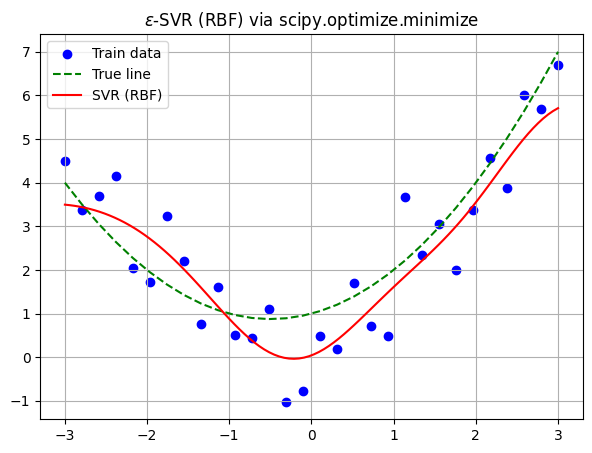

In [8]:
# 결과 시각화
plt.figure(figsize=(7,5))
plt.scatter(X, t, color='blue', label='Train data')
plt.plot(X, y_true, color='green', linestyle='--', label='True line')
plt.plot(X_test, y_pred, color='red', label='SVR (RBF)')

plt.title(r"$\varepsilon$-SVR (RBF) via scipy.optimize.minimize")
plt.legend()
plt.grid(True)
plt.show()

## 5. 총정리

- 슬랙 변수는 주어진 데이터에 대해 오분류와 마진 침범을 허용하는 방법으로, 데이터의 완벽한 분리가 불가능할 때 유용하며, 일반화 성능을 개선한다.
- Soft-Margin SVM은 데이터가 완벽하게 분리되지 않는 일반적인 경우에 적용 가능하며, 이 모델은 슬랙 변수를 도입하여 마진을 침범하는 일부 샘플을 허용함으로써 오버피팅을 방지하고 모델의 일반화 능력을 향상시킨다.
- SVR은 SVM의 기본 개념을 회귀 문제로 확장한 것으로, 연속적인 값을 예측할 수 있으며, $\varepsilon$-insensitive loss를 도입하여 예측 오차가 작은 경우에는 손실을 0으로 간주함으로써 모델의 성능을 증대시킨다.
- 하이퍼파라미터 $\gamma, \; C, \; \varepsilon$ 등을 바꾸어 가며 실험하면서, 과적합/과소적합 수준을 조절할 수 있다.